# LaDiff – `BaseLimitedAngleReconstructions` Dataset Demo

This notebook demonstrates the `BaseLimitedAngleReconstructions` dataset introduced
for the **ladiff** project.  The dataset builds FBP reconstructions by sliding a window
of length `total_projections` (1501) over the temporally-assembled combined sinogram
`total_sino` (shape `K_ANGLES × N_SLICES`, W) and running 2-D parallel-beam FBP.

**Sections**
1. Imports & parameters
2. Instantiate the dataset
3. Inspect `total_sino` and `total_angles`
4. Visualise FBP reconstructions for selected window positions

## 1. Imports & parameters

In [1]:
import sys, importlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

import lovely_tensors as lt
lt.monkey_patch()

# ── Path setup ────────────────────────────────────────────────────────────
project_root = Path('/myhome/sdate')
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')

# Reload to pick up edits without restarting the kernel
import sdate.limited_angle_tomo as _lat_mod
importlib.reload(_lat_mod)

from sdate.limited_angle_tomo import BaseLimitedAngleReconstructions

print('✅ Imports ready')
print(f'CUDA available: {torch.cuda.is_available()}')

Matplotlib is building the font cache; this may take a moment.


zarr not installed
✅ Imports ready
CUDA available: True


In [ ]:
# ── Data ──────────────────────────────────────────────────────────────────
DATA_PATH        = Path('/myhome/data/sdate/shared/compression_paper/file_10_extracted')
NUM_PROJECTIONS  = 1501
TARGET_SIZE      = (2560 // 4, 1762 // 4)
# NUM_PROJECTIONS  = 501
# TARGET_SIZE      = (1008 // 2, 1900 // 2)

# ── Limited-angle setup ───────────────────────────────────────────────────
N_SLICES  = 20      # time slices
K_ANGLES  = 400     # contiguous projections per slice

print(f'DATA_PATH   : {DATA_PATH}')
print(f'total_sino  length: {K_ANGLES * N_SLICES}  (= K_ANGLES × N_SLICES)')
print(f'window_size : {NUM_PROJECTIONS}  (= len(all_angles_deg))')
print(f'n_samples   : {K_ANGLES * N_SLICES - NUM_PROJECTIONS + 1}')

DATA_PATH   : /myhome/data/sdate/shared/compression_paper/file_10_extracted
total_sino  length: 8000  (= K_ANGLES × N_SLICES)
window_size : 1501  (= len(all_angles_deg))
n_samples   : 6500


## 2. Instantiate the dataset

`BaseLimitedAngleReconstructions.__init__` loads the full projection volume,
builds `LimitedAngleDataset`, and assembles `total_sino` / `total_angles`.
FBP is performed lazily in `__getitem__`.

In [6]:
dataset = BaseLimitedAngleReconstructions(
    data_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    n_slices=N_SLICES,
    k_angles=K_ANGLES,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    # height_offset=500,  # to roughly center the reconstruction FOV on the heart
    height_skip=20
)

print(f'\ndataset length : {len(dataset)}')
print(f'window_size    : {dataset._window_size}')
print(f'vol_shape      : {dataset.vol_shape}')
print(f'total_sino     : {dataset.total_sino.shape}')
print(f'total_angles   : min={dataset.total_angles.min():.1f}°  '
      f'max={dataset.total_angles.max():.1f}°')

✅ Found parameters in Al8Fe_10x_.log: {'num_darks': 32, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_10_extracted
   Total TIFF files: 1733
   Darks: 32, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 1762
   Use attenuation: True
✅ Loaded cached attenuation data from .tomography_cache_atten.npz
   Range: [0.4573, 2.4159]
ProjectionSliceDataset:
  Volume shape: (440, 640, 1501)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 281,600
Loading 1501 projections...
  Loaded 50/1501
  Loaded 100/1501
  Loaded 150/1501
  Loaded 200/1501
  Loaded 250/1501
  Loaded 300/1501
  Loaded 350/1501
  Loaded 400/1501
  Loaded 450/1501
  Loaded 500/1501
  Loaded 550/1501
  Loaded 600/1501
  Loaded 650/1501
  Loaded 700/1501
  Loaded 750/1501
  Loaded 800/1501
  Loaded 850/1501
  Loaded 900/1501
  Loaded 950/1501
  Loaded 1000/1501
  Loaded 1050/1501
  Loaded 1100/1501
  Loaded 1150/1501
  Loaded 1200/1501
  Loaded 1250/1501
  Loaded 1300/1501
  Loade

/myhome/sdate/sdate/limited_angle_tomo.py:428: UserWarning: [BaseLimitedAngleReconstructions] Normalization calibrated: p99=0.003725, norm_scale=268.4526. Reconstructions will be multiplied by 268.4526 to map them to ~[0, 1].
  self.norm_scale: float = self._calibrate_normalization(data_path)


## 3. Inspect `total_sino` and `total_angles`

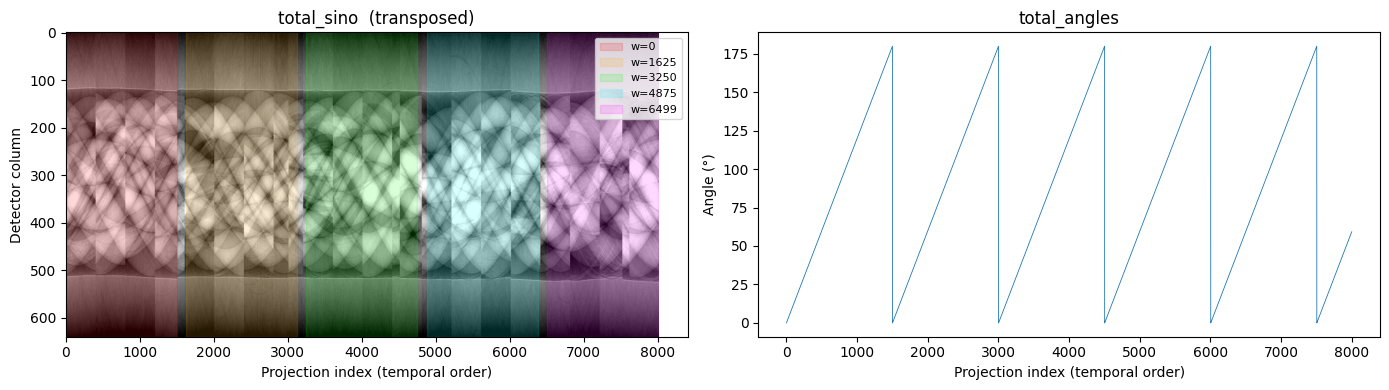

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sinogram image
axes[0].imshow(
    dataset.total_sino.cpu().T,
    aspect='auto', cmap='gray',
    vmin=float(dataset.total_sino.quantile(0.01)),
    vmax=float(dataset.total_sino.quantile(0.99)),
)
axes[0].set_xlabel('Projection index (temporal order)')
axes[0].set_ylabel('Detector column')
axes[0].set_title('total_sino  (transposed)')

# Highlight a few sliding windows
n_samples = len(dataset)
highlight_indices = [
    0,
    n_samples // 4,
    n_samples // 2,
    3 * n_samples // 4,
    n_samples - 1,
]
colours = ['red', 'orange', 'lime', 'cyan', 'magenta']
H = dataset.total_sino.shape[1]
for idx, col in zip(highlight_indices, colours):
    w_start = idx
    w_end   = idx + dataset._window_size
    axes[0].axvspan(w_start, w_end, alpha=0.15, color=col, label=f'w={idx}')
axes[0].legend(fontsize=8, loc='upper right')

# Angles plot
axes[1].plot(dataset.total_angles.cpu().numpy(), linewidth=0.6)
axes[1].set_xlabel('Projection index (temporal order)')
axes[1].set_ylabel('Angle (°)')
axes[1].set_title('total_angles')

plt.tight_layout()
plt.show()

## 4. Visualise FBP reconstructions for selected window positions

We call `dataset[idx]` for five evenly-spaced window positions and display the
resulting 2-D reconstructions side-by-side.

In [17]:
dataset.get_multiframe_data(10)['full_sinograms']

[tensor[1501, 640] n=960640 (3.7Mb) x∈[0.764, 2.075] μ=1.417 σ=0.232]

In [ ]:
n_samples = len(dataset)
window_positions = [
    0,
    n_samples // 4,
    n_samples // 2,
    3 * n_samples // 4,
    n_samples - 1,
]
window_positions = torch.arange(200, 20*400 - 1501, 200)

recons = []
for pos in window_positions:
    print(f'  Reconstructing window pos {pos} '
          f'(rows {pos}–{pos + dataset._window_size - 1}, '
          f'slice≈{dataset.which_slice(pos)}) …', end=' ', flush=True)
    recon = dataset[pos].cpu()  # (ny, nx)
    gt_recon = dataset.get_multiframe_data(pos)
    recons.append(recon)
    print(f'done  shape={recon.shape}  range=[{recon.min():.3f}, {recon.max():.3f}]')

print('All reconstructions finished.')

  Reconstructing window pos 200 (rows 200–1700, slice≈2) … done  shape=torch.Size([1, 640, 640])  range=[-1.803, 1.853]
  Reconstructing window pos 400 (rows 400–1900, slice≈2) … done  shape=torch.Size([1, 640, 640])  range=[-2.139, 1.837]
  Reconstructing window pos 600 (rows 600–2100, slice≈3) … done  shape=torch.Size([1, 640, 640])  range=[-2.108, 2.057]
  Reconstructing window pos 800 (rows 800–2300, slice≈3) … done  shape=torch.Size([1, 640, 640])  range=[-1.848, 1.995]
  Reconstructing window pos 1000 (rows 1000–2500, slice≈4) … done  shape=torch.Size([1, 640, 640])  range=[-1.767, 1.981]
  Reconstructing window pos 1200 (rows 1200–2700, slice≈4) … done  shape=torch.Size([1, 640, 640])  range=[-1.842, 1.874]
  Reconstructing window pos 1400 (rows 1400–2900, slice≈5) … done  shape=torch.Size([1, 640, 640])  range=[-1.860, 1.945]
  Reconstructing window pos 1600 (rows 1600–3100, slice≈5) … done  shape=torch.Size([1, 640, 640])  range=[-1.664, 1.734]
  Reconstructing window pos 1800

In [ ]:
from ipywidgets import interact
#use slider to scroll through reconstructions
@interact(pos=(0, len(window_positions)-1))
def show_recon(pos):
    recon = dataset[window_positions[pos]].cpu()[0]
    # Per-image percentile clipping for visibility
    vmin = 0.0
    vmax = float(torch.quantile(recon, 0.99))
    plt.imshow(recon.numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    plt.axis('off')
    plt.colorbar()
    plt.show()

interactive(children=(IntSlider(value=15, description='pos', max=31), Output()), _dom_classes=('widget-interac…

## 5. (Optional) Centre-slice reconstruction detail

Zoom in on the centre-most window to inspect artefacts.

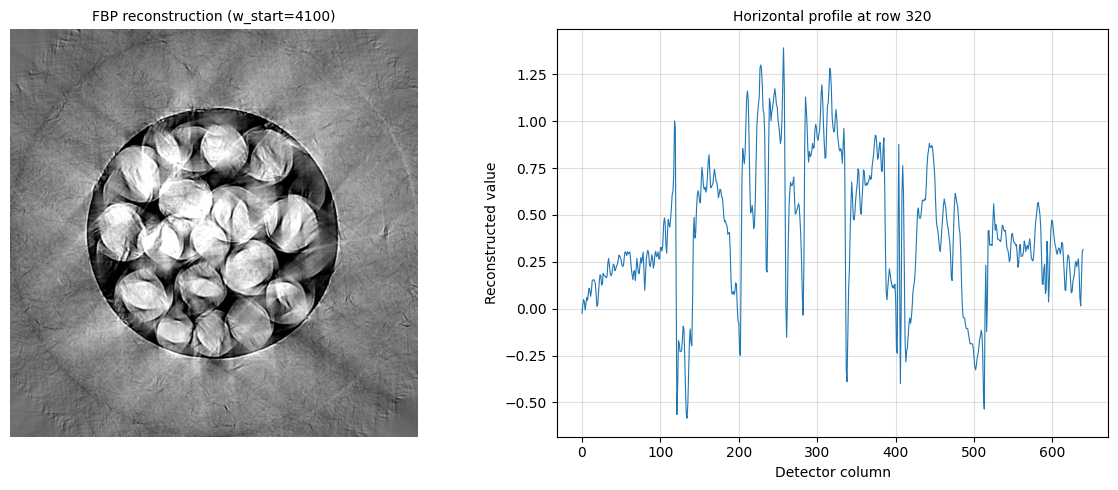

In [10]:
centre_pos = n_samples - 6 * 400
recon_centre = dataset[centre_pos].cpu()[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Full reconstruction
vmin = float(torch.quantile(recon_centre, 0.02))
vmax = float(torch.quantile(recon_centre, 0.98))
axes[0].imshow(recon_centre.numpy(), cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title(f'FBP reconstruction (w_start={centre_pos})', fontsize=10)
axes[0].axis('off')

# Horizontal profile through the centre row
cy = recon_centre.shape[0] // 2
axes[1].plot(recon_centre[cy].numpy(), linewidth=0.8)
axes[1].set_xlabel('Detector column')
axes[1].set_ylabel('Reconstructed value')
axes[1].set_title(f'Horizontal profile at row {cy}', fontsize=10)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()